# Profilo delle scadenze del debito pubblico

Questo notebook analizza il profilo delle scadenze dei titoli di Stato a partire dai file MEF normalizzati dal repository. I grafici mostrano quanto debito deve essere rinnovato per anno, quanto pesa ogni anno sul totale e qual e' la vita media residua stimata.

La vita media residua e' calcolata sulle singole date di scadenza disponibili nel file MEF, ponderando ogni titolo per il circolante euro rivalutato. Non e' una duration finanziaria, perche' non considera cedole, prezzi e flussi intermedi.

In [1]:
from pathlib import Path
import json

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PRIMARY = "#1f77b4"
SECONDARY = "#d62728"
ACCENT = "#2ca02c"
MUTED = "#6b7280"
GRID = "#e5e7eb"
TEXT = "#111827"
COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#cbd5e1",
    "axes.labelcolor": TEXT,
    "axes.titlecolor": TEXT,
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "text.color": TEXT,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
})


def repo_root():
    cwd = Path.cwd()
    candidates = [cwd, cwd.parent]
    for candidate in candidates:
        if (candidate / "output" / "data" / "public" / "debito-pubblico.json").exists():
            return candidate
    raise FileNotFoundError("Eseguire prima: python scripts/build_all_datasets.py")


ROOT = repo_root()
DATA_FILE = ROOT / "output" / "data" / "public" / "debito-pubblico.json"

with DATA_FILE.open(encoding="utf-8") as file:
    payload = json.load(file)


def points_frame(record, value_index=2, value_name="value"):
    rows = record.get("points", []) if record else []
    df = pd.DataFrame(rows)
    if df.empty:
        return pd.DataFrame(columns=["date", value_name])
    df = df.rename(columns={0: "date", value_index: value_name})[["date", value_name]]
    df["date"] = pd.to_datetime(df["date"], errors="coerce")
    df[value_name] = pd.to_numeric(df[value_name], errors="coerce")
    return df.dropna().sort_values("date")


def euro_format(value, decimals=0):
    if value is None or pd.isna(value):
        return "ND"
    return f"{value:,.{decimals}f}".replace(",", "X").replace(".", ",").replace("X", ".")


def format_mld_axis(value, pos):
    return euro_format(value, 0)


def format_pct_axis(value, pos):
    return f"{value:.0f}%".replace(".", ",")


def add_credit(fig, source):
    fig.text(
        0.01,
        0.01,
        f"Fonte: {source}. Elaborazione di Nazareno Lecis.",
        ha="left",
        va="bottom",
        color=MUTED,
        fontsize=9,
    )


def finish(ax, title, subtitle, source, ylabel=None, percent=False, format_y=True):
    fig = ax.figure
    ax.set_title(title, loc="left", fontsize=16, color=TEXT, pad=18)
    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes, color=MUTED, fontsize=10, ha="left", va="bottom")
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(True, axis="y", color=GRID, linewidth=0.8)
    ax.grid(True, axis="x", color=GRID, linewidth=0.5, alpha=0.55)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if format_y:
        if percent:
            ax.yaxis.set_major_formatter(FuncFormatter(format_pct_axis))
        else:
            ax.yaxis.set_major_formatter(FuncFormatter(format_mld_axis))
    add_credit(fig, source)
    fig.tight_layout(rect=[0, 0.05, 1, 0.94])
    return fig, ax


def latest_label(df, value_col, suffix):
    if df.empty:
        return "Ultimo dato non disponibile"
    row = df.iloc[-1]
    return f"Ultimo dato: {row['date'].date()} - {euro_format(row[value_col], 1)} {suffix}"

## Dati di base

Il profilo usa lo snapshot MEF piu' recente presente nel payload. Le quote sono calcolate sul totale del circolante rivalutato incluso nel profilo scadenze.

In [2]:
profile = payload["maturity_profile"]
yearly = pd.DataFrame(profile["yearly"])
quarterly = pd.DataFrame(profile["quarterly"])

for frame in [yearly, quarterly]:
    frame["amount_bln_eur_revalued"] = pd.to_numeric(frame["amount_bln_eur_revalued"], errors="coerce")
    frame["share_percent"] = pd.to_numeric(frame["share_percent"], errors="coerce")

yearly["year"] = yearly["year"].astype(int)
quarterly["year"] = quarterly["year"].astype(int)
weighted_average = profile.get("weighted_average_residual_years")
print(f"Snapshot MEF: {profile.get('snapshot_date')}")
print(f"Totale profilo: {euro_format(profile.get('total_amount_bln_eur_revalued'), 1)} mld euro")
print(f"Vita media residua stimata: {euro_format(weighted_average, 1)} anni")

Snapshot MEF: 2026-05-31
Totale profilo: 3.043,4 mld euro
Vita media residua stimata: 7,0 anni


## Ammontare in scadenza per anno

Le barre indicano il circolante rivalutato che arriva a scadenza in ciascun anno. Il picco nei primi anni segnala il volume che deve essere rifinanziato nel breve periodo.

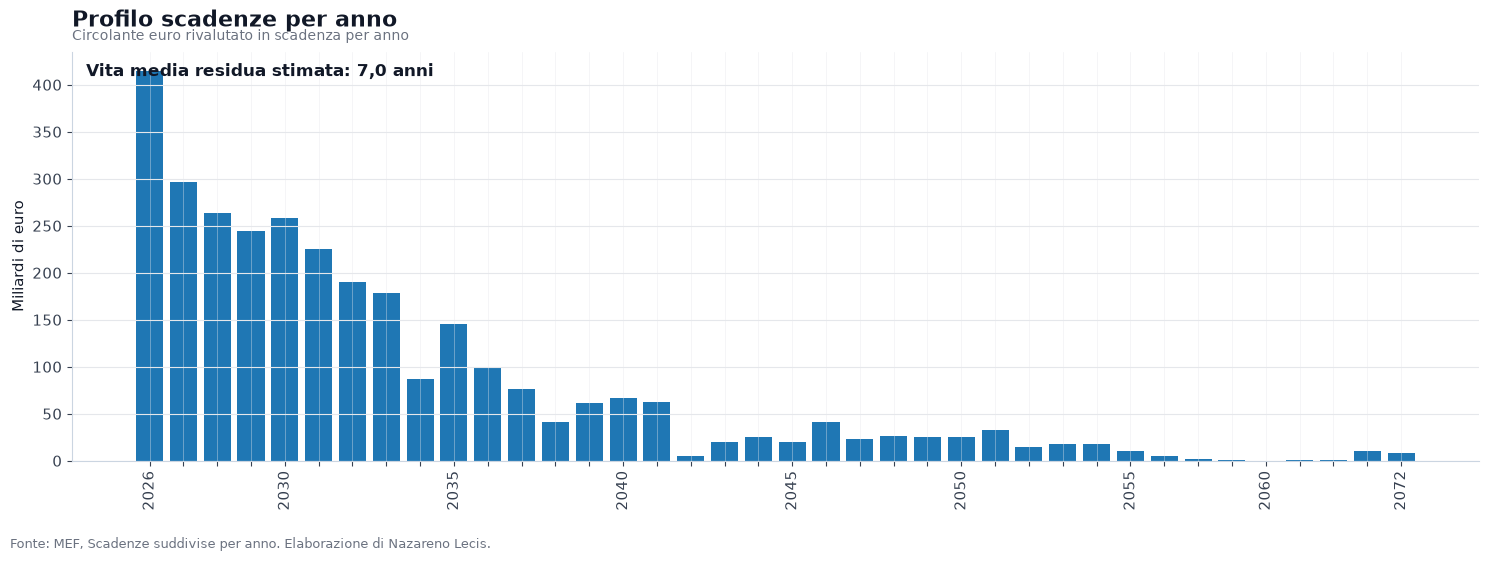

In [3]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(yearly["year"].astype(str), yearly["amount_bln_eur_revalued"], color=PRIMARY)
ax.text(0.01, 0.94, f"Vita media residua stimata: {euro_format(weighted_average, 1)} anni", transform=ax.transAxes, color=TEXT, fontsize=12, fontweight="bold")
for index, label in enumerate(ax.get_xticklabels()):
    year = int(label.get_text())
    label.set_visible(year % 5 == 0 or index in [0, len(yearly) - 1])
    label.set_rotation(90)
finish(
    ax,
    "Profilo scadenze per anno",
    "Circolante euro rivalutato in scadenza per anno",
    "MEF, Scadenze suddivise per anno",
    ylabel="Miliardi di euro",
)
plt.show()

## Quota in scadenza per anno

La stessa informazione puo' essere letta come percentuale del totale del profilo. Questa vista aiuta a confrontare il peso relativo dei singoli anni senza essere guidati soltanto dagli importi assoluti.

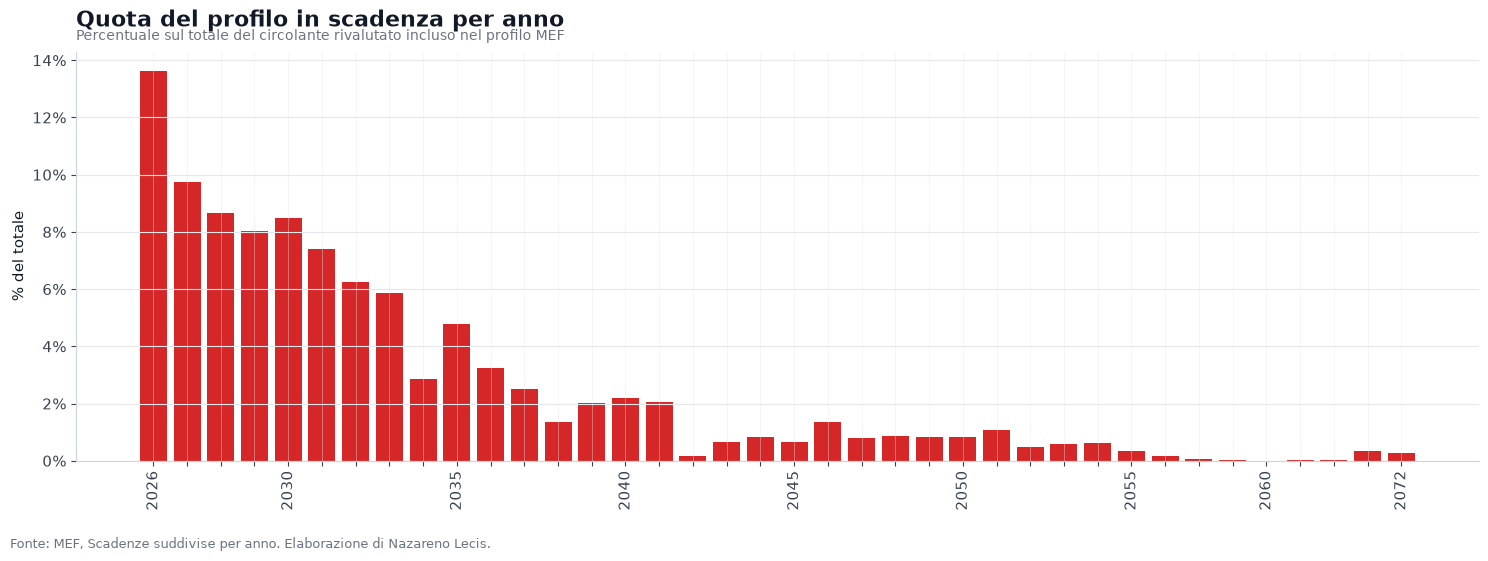

In [4]:
fig, ax = plt.subplots(figsize=(15, 6))
ax.bar(yearly["year"].astype(str), yearly["share_percent"], color=SECONDARY)
for index, label in enumerate(ax.get_xticklabels()):
    year = int(label.get_text())
    label.set_visible(year % 5 == 0 or index in [0, len(yearly) - 1])
    label.set_rotation(90)
finish(
    ax,
    "Quota del profilo in scadenza per anno",
    "Percentuale sul totale del circolante rivalutato incluso nel profilo MEF",
    "MEF, Scadenze suddivise per anno",
    ylabel="% del totale",
    percent=True,
)
plt.show()

## Profilo trimestrale dei prossimi anni

La tabella-grafico sotto mostra dove si concentra il debito in scadenza nei trimestri piu' vicini. E' utile per distinguere anni con distribuzione uniforme da anni concentrati in una o due finestre.

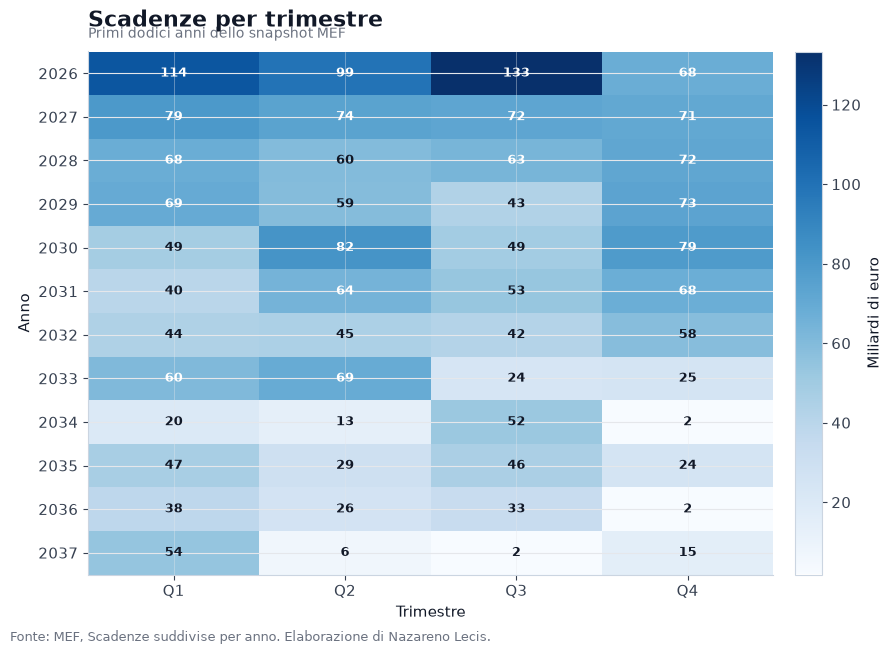

In [5]:
recent_quarters = quarterly[quarterly["year"] <= quarterly["year"].min() + 11].copy()
pivot = recent_quarters.pivot_table(index="year", columns="quarter", values="amount_bln_eur_revalued", aggfunc="sum").fillna(0)

fig, ax = plt.subplots(figsize=(9, 7))
image = ax.imshow(pivot.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
for y in range(pivot.shape[0]):
    for x in range(pivot.shape[1]):
        value = pivot.values[y, x]
        if value > 0:
            ax.text(x, y, euro_format(value, 0), ha="center", va="center", color="white" if value > pivot.values.max() * 0.45 else TEXT, fontsize=9, fontweight="bold")
fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03, label="Miliardi di euro")
finish(
    ax,
    "Scadenze per trimestre",
    "Primi dodici anni dello snapshot MEF",
    "MEF, Scadenze suddivise per anno",
    ylabel="Anno",
    format_y=False,
)
ax.set_xlabel("Trimestre")
plt.show()